In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clustered dataset from Day 4
df = pd.read_csv(r"C:\Users\vidisha bhat\Downloads\archive\spotify_clustered.csv")

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (89741, 23)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,pca1,pca2
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3,0.687034,1.048990
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,0,-3.189236,1.035552
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,0,-1.315996,-0.216949
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,0,-3.189120,-0.499169
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,0,-0.886528,0.271098


In [2]:
# Create the Hit/Flop label
# Hit = popularity > 70, Flop = popularity <= 70
df['is_hit'] = (df['popularity'] > 70).astype(int)

print("Hit vs Flop distribution:")
print(df['is_hit'].value_counts())
print(f"\nPercentage of hits: {df['is_hit'].mean()*100:.2f}%")

Hit vs Flop distribution:
is_hit
0    87008
1     2733
Name: count, dtype: int64

Percentage of hits: 3.05%


In [3]:
# Select features for classification
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 
            'valence', 'tempo', 'duration_ms', 'explicit']

X = df[features]
y = df['is_hit']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nHit percentage in training:", y_train.mean()*100, "%")
print("Hit percentage in testing:", y_test.mean()*100, "%")

Training set size: (71792, 11)
Testing set size: (17949, 11)

Hit percentage in training: 3.0449075105861376 %
Hit percentage in testing: 3.0475235389158173 %


In [4]:
# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Hit/Flop Classification Results:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

Hit/Flop Classification Results:
Accuracy: 0.838
Precision: 0.080
Recall: 0.411
F1 Score: 0.134


In [5]:
# Try a more balanced threshold
df['is_hit_v2'] = (df['popularity'] > 60).astype(int)

print("New Hit vs Flop distribution:")
print(df['is_hit_v2'].value_counts())
print(f"Percentage of hits: {df['is_hit_v2'].mean()*100:.2f}%")

New Hit vs Flop distribution:
is_hit_v2
0    80906
1     8835
Name: count, dtype: int64
Percentage of hits: 9.84%


In [6]:
# Retrain with the new threshold
y_v2 = df['is_hit_v2']

X_train, X_test, y_train, y_test = train_test_split(X, y_v2, test_size=0.2, random_state=42, stratify=y_v2)

rf_classifier_v2 = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1, class_weight='balanced')
rf_classifier_v2.fit(X_train, y_train)

y_pred_v2 = rf_classifier_v2.predict(X_test)

accuracy_v2 = accuracy_score(y_test, y_pred_v2)
precision_v2 = precision_score(y_test, y_pred_v2)
recall_v2 = recall_score(y_test, y_pred_v2)
f1_v2 = f1_score(y_test, y_pred_v2)

print("Improved Hit/Flop Classification Results (threshold=60):")
print(f"Accuracy: {accuracy_v2:.3f}")
print(f"Precision: {precision_v2:.3f}")
print(f"Recall: {recall_v2:.3f}")
print(f"F1 Score: {f1_v2:.3f}")

Improved Hit/Flop Classification Results (threshold=60):
Accuracy: 0.728
Precision: 0.182
Recall: 0.504
F1 Score: 0.267


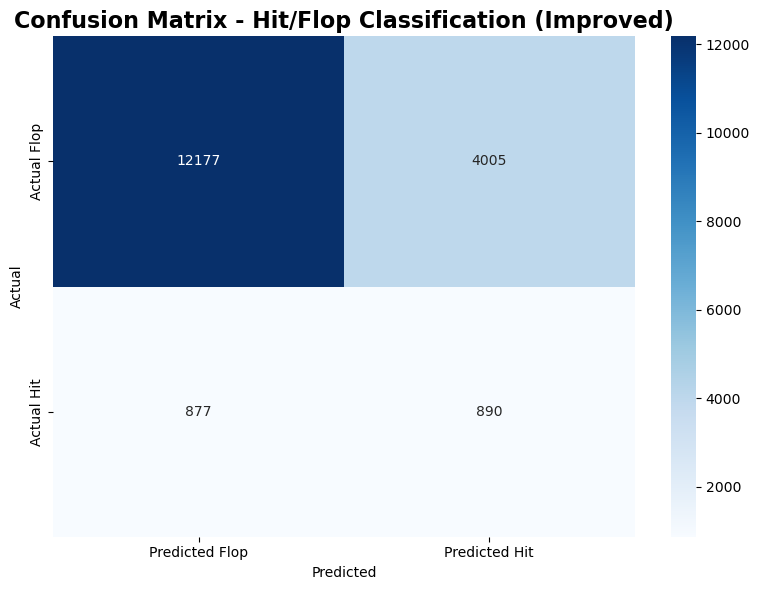

Confusion matrix saved!


In [7]:
# Confusion Matrix for the improved model (threshold=60)
cm = confusion_matrix(y_test, y_pred_v2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Flop', 'Predicted Hit'],
            yticklabels=['Actual Flop', 'Actual Hit'])
plt.title('Confusion Matrix - Hit/Flop Classification (Improved)', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('chart9_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

In [8]:
print("Day 6 Summary:")
print(f"Original model (threshold=70): F1 = {f1:.3f}")
print(f"Improved model (threshold=60): F1 = {f1_v2:.3f}")
print(f"Improvement: {((f1_v2-f1)/f1*100):.1f}% increase in F1 score")
print("\nDay 6 (Hit/Flop Classification) complete!")

Day 6 Summary:
Original model (threshold=70): F1 = 0.134
Improved model (threshold=60): F1 = 0.267
Improvement: 99.4% increase in F1 score

Day 6 (Hit/Flop Classification) complete!
